# Modelos y métricas

Este notebook compara un baseline Dummy, regresión logística y random forest sobre los splits temporales de InvoiceOps. Todos los modelos se entrenan con `train.csv` y se evalúan solo con `validation.csv`. `test.csv` no se lee ni se usa para fit, métricas, selección o conclusiones.

In [1]:
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.tree import plot_tree

from invoiceops.ml.data import TARGET, generate_synthetic_dataset
from invoiceops.ml.features import MODEL_FEATURES
from invoiceops.ml.metrics import evaluate_binary_classifier
from invoiceops.ml.pipelines import (
    build_dummy_pipeline,
    build_logistic_pipeline,
    build_random_forest_pipeline,
)

# El dataset efímero conserva rutas relativas y no deja data/ en el repositorio.
with tempfile.TemporaryDirectory(prefix="invoiceops-models-", dir=".") as temporary_dir:
    output_root = Path(temporary_dir) / "data"
    output_root.mkdir()
    dataset_dir = generate_synthetic_dataset(
        seed=20260826, rows=12_000, version="invoice-risk-v1", output_root=output_root
    )
    train = pd.read_csv(dataset_dir / "train.csv")
    validation = pd.read_csv(dataset_dir / "validation.csv")

X_train, y_train = train[MODEL_FEATURES], train[TARGET]
X_validation, y_validation = validation[MODEL_FEATURES], validation[TARGET]
print(f"train={len(train):,}; validation={len(validation):,}; test no se usa")
print(f"Clase positiva en train: {y_train.mean():.1%}; clase mayoritaria: {y_train.mode().iat[0]}")

train=8,400; validation=1,800; test no se usa
Clase positiva en train: 22.2%; clase mayoritaria: False


## Dummy: baseline, clase mayoritaria e imbalance

`DummyClassifier(strategy='prior')` no aprende patrones de las features: devuelve la distribución de clases observada en train y predice la clase mayoritaria. Con una clase positiva minoritaria, accuracy puede parecer alta mientras precision, recall y F1 para revisión manual son nulos.

In [2]:
factories = {
    "Dummy": build_dummy_pipeline,
    "Logistic": build_logistic_pipeline,
    "Random forest": build_random_forest_pipeline,
}
models = {}
metrics_by_model = {}
predictions_by_model = {}
probabilities_by_model = {}

for name, factory in factories.items():
    model = factory().fit(X_train, y_train)
    predictions = model.predict(X_validation)
    probabilities = model.predict_proba(X_validation)[:, 1]
    models[name] = model
    predictions_by_model[name] = predictions
    probabilities_by_model[name] = probabilities
    metrics_by_model[name] = evaluate_binary_classifier(y_validation, predictions, probabilities)

comparison = pd.DataFrame(metrics_by_model).T
display(comparison.round(3))
print("Dummy predicted positive:", int(predictions_by_model["Dummy"].sum()), "of", len(validation))

,accuracy,precision,recall,f1,roc_auc
Dummy,0.791,0.000,0.000,0.000,0.500
Logistic,0.800,0.635,0.106,0.182,0.667
Random forest,0.788,0.486,0.186,0.269,0.644


Dummy predicted positive: 0 of 1800


## Regresión logística: métricas, matriz y coeficientes

La regresión logística aplica una función link sigmoide al score lineal y produce probabilidades. Sus coeficientes describen asociación condicional dentro de este dataset y esta representación de features; no prueban causalidad.

,coefficient
categorical__country_risk_low,-0.447
boolean__has_purchase_order,-0.418
boolean__three_way_match,-0.381
numeric__vendor_tenure_days,-0.325
categorical__country_risk_medium,-0.259
numeric__invoice_amount_cents,0.072
numeric__amount_vs_vendor_median,0.163
categorical__country_risk_high,0.253
numeric__previous_incidents_12m,0.346
boolean__bank_account_recently_changed,0.874


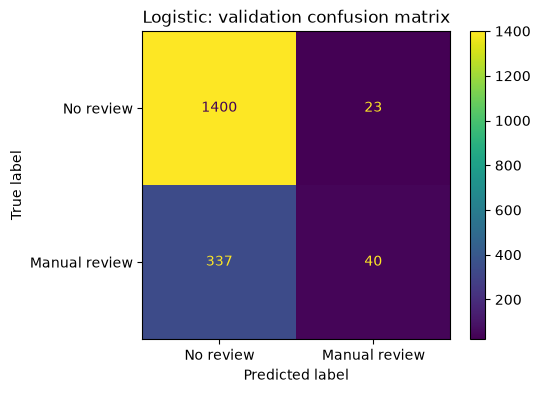

In [3]:
logistic = models["Logistic"]
logistic_classifier = logistic.named_steps["classifier"]
logistic_features = logistic.named_steps["preprocessor"].get_feature_names_out()
coefficients = pd.Series(logistic_classifier.coef_[0], index=logistic_features).sort_values()

display(coefficients.to_frame("coefficient").round(3))
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_validation,
    predictions_by_model["Logistic"],
    display_labels=["No review", "Manual review"],
    ax=ax,
)
ax.set_title("Logistic: validation confusion matrix")
plt.show()

## Score, sigmoide y BCE

Para un score lineal `z`, la logística calcula `p = sigmoid(z) = 1 / (1 + exp(-z))`. La binary cross-entropy (BCE) penaliza probabilidades seguras equivocadas: `BCE = -[y log(p) + (1-y) log(1-p)]`. La probabilidad estimada por ML no decide sola una política: el umbral operativo debe reflejar el trade-off entre falsos positivos y falsos negativos.

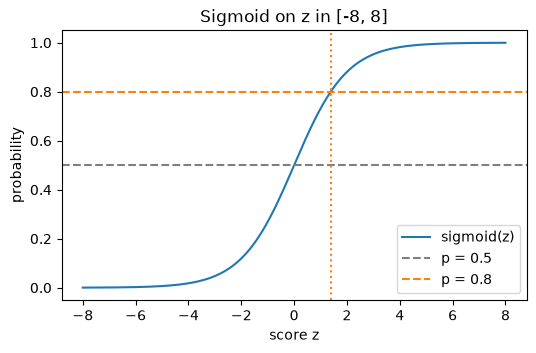

Logistic returns probabilities; a p >= 0.8 policy would review 1 validation invoices.


In [4]:
z = np.linspace(-8, 8, 401)
probability = 1 / (1 + np.exp(-z))
p80_score = np.log(0.8 / 0.2)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(z, probability, label="sigmoid(z)")
ax.axhline(0.5, color="tab:gray", linestyle="--", label="p = 0.5")
ax.axhline(0.8, color="tab:orange", linestyle="--", label="p = 0.8")
ax.axvline(p80_score, color="tab:orange", linestyle=":")
ax.set(xlabel="score z", ylabel="probability", ylim=(-0.05, 1.05), title="Sigmoid on z in [-8, 8]")
ax.legend(loc="lower right")
plt.show()

policy_threshold = 0.8  # Illustrative policy, not selected using test.csv.
policy_reviews = (probabilities_by_model["Logistic"] >= policy_threshold).sum()
print(
    f"Logistic returns probabilities; a p >= {policy_threshold:.1f} policy would review {policy_reviews} validation invoices."
)

## Random forest: métricas, importancia y un árbol real

El bosque combina muchos árboles. Cada nodo reduce impureza Gini, `1 - sum(p_k²)`: vale 0 si el nodo contiene una sola clase. La figura siguiente visualiza solo los primeros tres niveles de `estimators_[0]`, un árbol ya entrenado por el random forest; no crea un cuarto `DecisionTreeClassifier`. Las importancias agregadas muestran reducción de impureza, no causalidad ni una garantía de estabilidad con features correlacionadas.

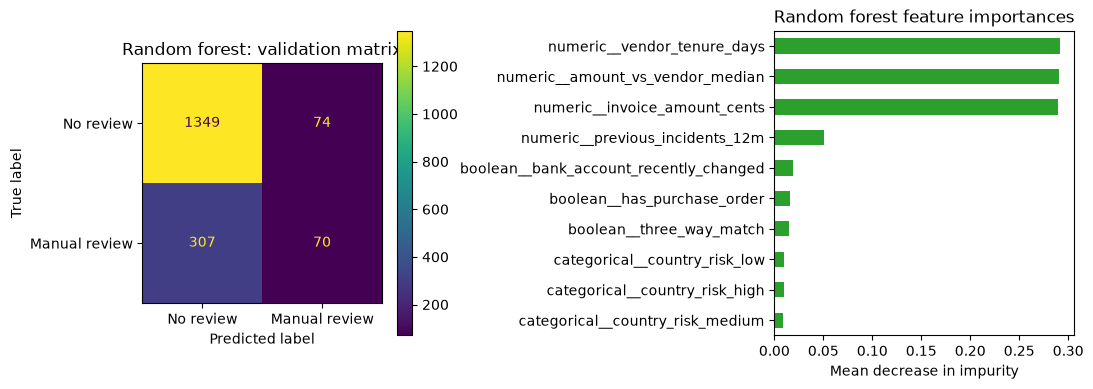

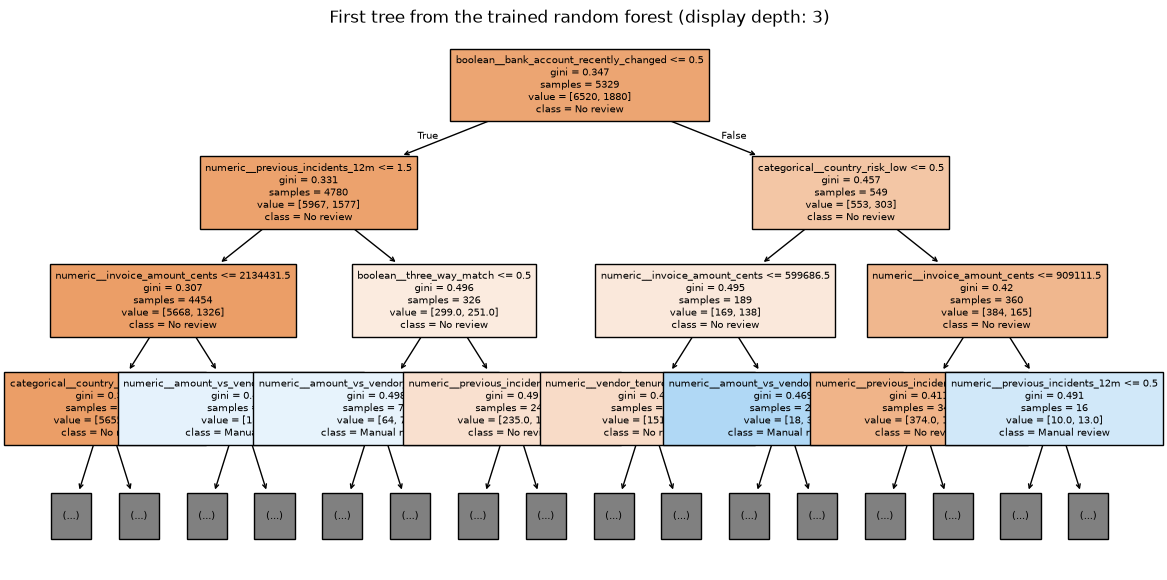

In [5]:
random_forest = models["Random forest"]
forest_classifier = random_forest.named_steps["classifier"]
forest_features = random_forest.named_steps["preprocessor"].get_feature_names_out()
importances = pd.Series(forest_classifier.feature_importances_, index=forest_features).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay.from_predictions(
    y_validation,
    predictions_by_model["Random forest"],
    display_labels=["No review", "Manual review"],
    ax=axes[0],
)
axes[0].set_title("Random forest: validation matrix")
importances.plot.barh(ax=axes[1], color="tab:green")
axes[1].set(title="Random forest feature importances", xlabel="Mean decrease in impurity")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(14, 7))
plot_tree(
    forest_classifier.estimators_[0],
    feature_names=forest_features,
    class_names=["No review", "Manual review"],
    filled=True,
    max_depth=3,
    fontsize=7,
    ax=ax,
)
ax.set_title("First tree from the trained random forest (display depth: 3)")
plt.show()

## Activaciones y cierre

Dummy y random forest no usan una activation function. La regresión logística usa la sigmoide como link entre score y probabilidad. En redes neuronales, Sigmoid transforma valores a `(0, 1)`, ReLU conserva valores positivos y corta los negativos, y Softmax normaliza scores de varias clases. Este notebook no entrena redes neuronales.

La tabla final compara todos los modelos en validation. Preguntas para discutir: ¿cuánto recall adicional justifica más falsos positivos y carga de revisión? ¿Qué coste o capacidad operativa debería informar un umbral de política distinto de 0.5? ¿Por qué no debemos inferir causalidad desde coeficientes o importancias?

In [6]:
display(comparison.loc[["Dummy", "Logistic", "Random forest"]].round(3))
print("All reported metrics use validation.csv only; test.csv remains held out.")

,accuracy,precision,recall,f1,roc_auc
Dummy,0.791,0.000,0.000,0.000,0.500
Logistic,0.800,0.635,0.106,0.182,0.667
Random forest,0.788,0.486,0.186,0.269,0.644


All reported metrics use validation.csv only; test.csv remains held out.
